In [1]:
pip install shap


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv("../data/heart_failure_clinical_records_dataset.csv")
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### A Random Forest classifier with 500 trees was used to model the relationship between clinical features and mortality risk. The model uses bootstrap sampling and random feature selection at each split to reduce overfitting and improve generalization. Class weights were balanced to account for the class imbalance between survivors and non-survivors.

In [3]:
import shap
import numpy as np

# background for baseline 
background = X_train.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf, data=background)

# explain test explorations
X_explain = X_test.copy()
shap_values = explainer.shap_values(X_explain)

In [4]:
# SHAP for class1 (DEATH_EVENT=1),  "death"
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
else:
    shap_class1 = shap_values

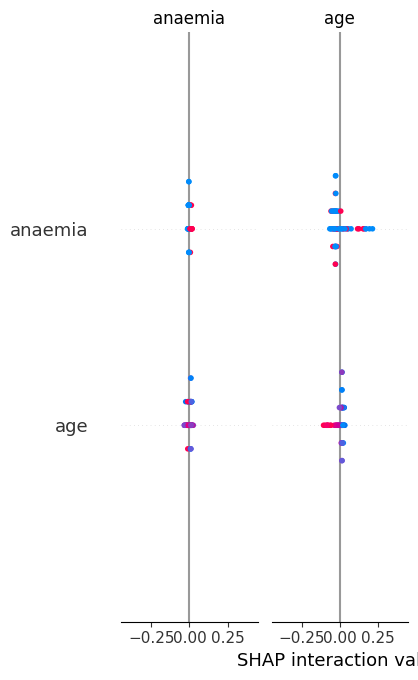

In [5]:
shap.summary_plot(shap_class1, X_explain)

### The SHAP interaction plot between age and anaemia shows that the interaction effect between these two variables is relatively small. Most interaction values are centered around zero, indicating that the combined influence of age and anaemia does not significantly amplify mortality risk beyond their individual contributions. This suggests that these variables mainly affect the model prediction independently rather than through strong interaction effects.

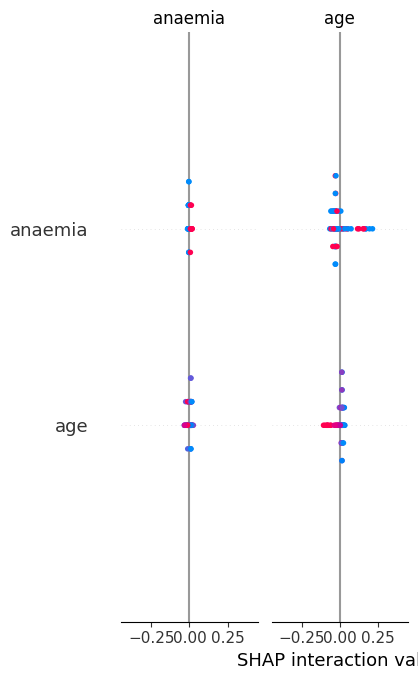

In [6]:
shap.summary_plot(shap_class1, X_explain)

### The SHAP summary plot shows that features related to cardiac function (ejection fraction), renal function (serum creatinine), and patient age have the strongest influence on the model predictions. Lower ejection fraction and higher serum creatinine values are associated with increased mortality risk, while higher ejection fraction tends to reduce the predicted risk. These findings align with known clinical mechanisms in heart failure.

### This project demonstrates that machine learning models can effectively predict mortality risk in heart failure patients using routinely collected clinical variables. The results highlight the importance of cardiac function, kidney function, and patient age in determining prognosis, and illustrate how explainable AI methods such as SHAP can help interpret model predictions in a clinically meaningful way.

In [7]:
pip install joblib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
